# Varying gammma
It seems that the distance function in a realistic test setting does indeed increase the absolute difference in OT cost in the specific example tested before. However, we want to ensure this effect is as noticable as possible. To this end, we'll test this example with different values for gamma.

## Imports

In [1]:
# Enabling Fast Reload 
%load_ext autoreload
%autoreload 2

# Imports
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicvisutils import hic_vis_matrix
from hicdatautils import hic_ot_source_to_targets, dist_weights

## Helper Functions

In [ ]:
def generate_single_cloud_matrix(size: int, dist: int, intensity: int=1000, width: int= None,
                                    height: int=None, center_index: int=None):
    '''
        Generates a synthethic contact map with a single point cloud at a fixed distance
        from the diagonal.

        Parameters
        ----------
        size : int
            Size of the contact map (size x size).
        dist : int
            Distance of the center of the point cloud from the major diagonal.
        intensity : int
            Maximum value of reads within the point cloud.
            Default = 1000.
        width : int
            The width of the point cloud along the targeted diagonal.
            Default = None, calculated based on cloud size.
        height : int
            The height of the point cloud across diagonals.
            Default = None, calculated based on cloud size.
        center_index : int
            The index of the center of the point cloud on the given diagonal.
            Default = None, uses middle of given diagonal.
        
        Returns
        -------
        matrix : np.ndarray
            Symmetric synthetic contact map.
    '''
    # Value errors
    if dist < 0 or dist >= size:
        raise ValueError(f"dist is not within matrix size (dist={dist}, allowed values: 0 - {size-1})")
    if center_index is not None and (center_index < 0 or center_index >= (size - dist)):
        raise ValueError(f"center_index is not within range allowed for given dist (center_index={center_index}, allowed values: 0 - {size-dist})")
    if (width is not None and width < 0) or (height is not None and height < 0):
        raise ValueError(f"Point cloud width and height must be higher than 0 (height={height}, width={width})")

    # Set center_index
    if center_index is None:
        center_index = (size - dist)/2
    
    i0 = center_index
    j0 = center_index + dist

    # Set cloud size
    if width is None:
        width = max(1, size // 20)
    if height is None:
        height = max(1, size // 80)
    
    sigma_width = width / 2
    sigma_height = height / 2

    # Defining coordinate grid
    x, y = np.meshgrid(np.arange(size), np.arange(size), indexing="ij")

    dx = x - i0
    dy = y - j0

    # Rotate onto diagonal
    u_width = (dx + dy) / np.sqrt(2)
    u_height = (dx - dy) / np.sqrt(2)

    # Gaussian blob for point cloud
    blob = intensity * np.exp(
        -(u_width**2 / (2 * sigma_width**2) 
        + u_height**2 / (2 * sigma_height**2))
    )

    # Make matrix symmetrical
    matrix = blob + blob.T

    # Ensure integers
    matrix = np.rint(matrix).astype(int)

    return matrix

## Generating Data

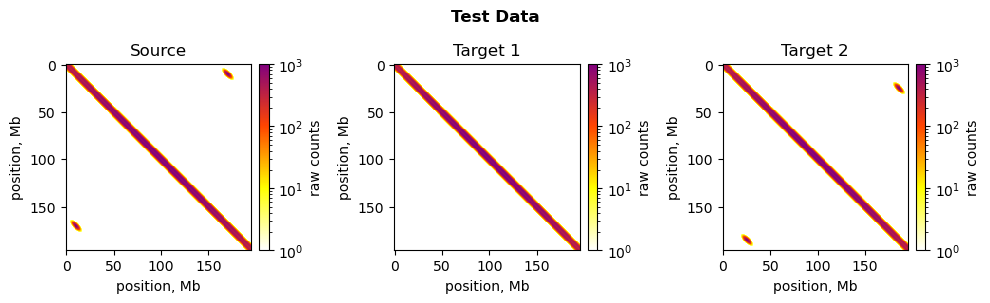

In [ ]:
### Creating maps ###
n = 196
dist_near = 2
dist_far = 160
w_near = 200
w_far = 5
int_far = 100
source_ci = 10
target_ci = 25

    # Source map
major = generate_single_cloud_matrix(size=n, dist=dist_near, width=w_near)
source_far = generate_single_cloud_matrix(size=n, dist=dist_far, width=w_far, center_index=source_ci)
source_map = major + source_far

    # Target map
target_far = generate_single_cloud_matrix(size=n, dist=dist_far, width=w_far, center_index=target_ci)
target_map = major + target_far
target_maps = [major, target_map]

    # Visualizing
fig, axs = plt.subplots(1, 3, figsize=(10, 3))
axes_flatten = axs.flatten()
hic_vis_matrix(source_map, "Source", ax=axes_flatten[0], cmap='higlass')
hic_vis_matrix(major, "Target 1", ax=axes_flatten[1], cmap='higlass')
hic_vis_matrix(target_map, "Target 2", ax=axes_flatten[2], cmap='higlass')

plt.suptitle("Test Data", fontweight="bold")
plt.tight_layout()

In [19]:
### Unscaled Data ###
simp_ot_unscaled = hic_ot_source_to_targets(source_map, target_maps, norm='sum')
unscaled_abs_dif = (simp_ot_unscaled[0] - simp_ot_unscaled[1])
unscaled_rel_dif = unscaled_abs_dif/simp_ot_unscaled[1]

## Helper Function OT

In [ ]:
def perform_ot_test(gamma: float):
    '''
        Performs OT from source to target 1 and target 2 for a given
        gamma value and compares this to unscaled OT.

        Function is specific to this notebook

        Parameters
        ----------
        gamma : float
            Gamma value to use for distance scaling.
        
        Returns
        -------
        ot_results : list
            List of OT results (target 1 and target 2)
        abs_dif : float
            Absolute difference between OT results.
        rel_dif : float
            Relative difference between OT results.
    '''
    # OT
    scaled_maps = []
    scaled_ref = dist_weights(source_map, gamma=gamma)
    for map in target_maps:
        scaled_maps.append(dist_weights(map, gamma=gamma))
    ot_results = hic_ot_source_to_targets(scaled_ref, scaled_maps, norm='sum')

    # Absolute difference
    abs_dif = ot_results[0] - ot_results[1]

    # Relative difference
    rel_dif = abs_dif/ot_results[1]

    return ot_results, abs_dif, rel_dif

## Performing gamma test

In [11]:
### Gamma Testing ###
    # Setting parameters
gammas = np.arange(0.25, 4.01, 0.25)

    # Initializing empty data
raw_values = []
abs_diffs = []
rel_diffs = []

    # Performing OT
for g in gammas:
    raw_value, abs_dif, rel_dif = perform_ot_test(g)
    raw_values.append(raw_value)
    abs_diffs.append(abs_dif)
    rel_diffs.append(rel_dif)

Text(0.5, 1.0, 'Absolute differences over gamma')

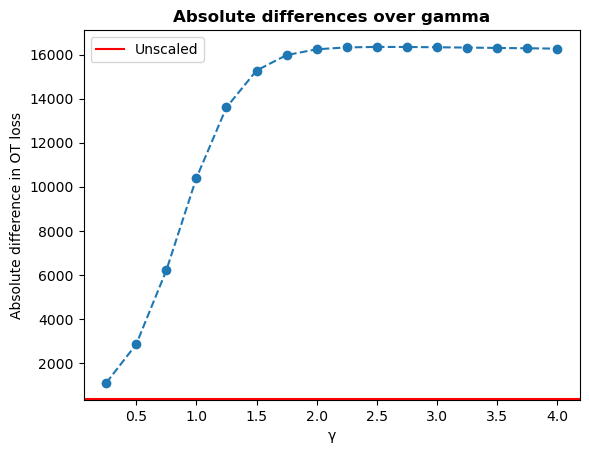

In [24]:
### Graphing absolute differences ###
plt.plot(gammas, abs_diffs, marker='o', linestyle="--")
plt.xlabel("γ")
plt.ylabel("Absolute difference in OT loss")
plt.axhline(unscaled_abs_dif, color="red", label="Unscaled")
plt.legend()
plt.title("Absolute differences over gamma", fontweight="bold")

Text(0.5, 1.0, 'Relative differences over gamma')

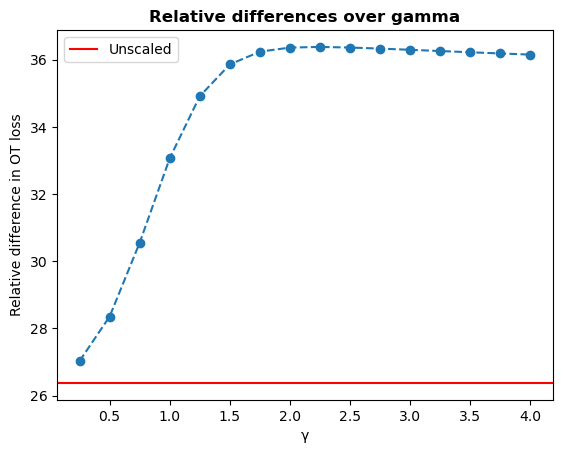

In [25]:
### Graphing relative differences ###
plt.plot(gammas, rel_diffs, marker='o', linestyle="--")
plt.xlabel("γ")
plt.ylabel("Relative difference in OT loss")
plt.axhline(unscaled_rel_dif, color="red", label="Unscaled")
plt.legend()
plt.title("Relative differences over gamma", fontweight="bold")